# 1. Noninteracting benchmark notebook

这个 notebook 只检查单粒子部分 `noninteracting.py`。

目标不是追求数值上最漂亮，而是先排查有没有 **根本的物理/逻辑错误**：

- 哈密顿量是否 Hermitian
- spinful 版本是否真的是 block diagonal
- `EF_from_filling` 和 `filling_from_EF` 是否互相一致
- 在一些简单极限下，能带和自旋简并是否合理

你运行完之后，把输出结果和 notebook 返回给我，我来帮你判断哪些是“重大物理错误”，哪些只是后续可改进项。


In [1]:
import os, sys, math, cmath
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/mnt/data')

from noninteracting import KagomeNagaosa, KagomeStaggerFlux, KagomeKaneMeleSOC
from patching import FSPatcher
from interaction import BareExtendedHubbard
from channels import ChannelDecomposer

RESULTS = []

def record(name, passed, detail='', value=None):
    RESULTS.append({
        'test': name,
        'passed': bool(passed),
        'detail': str(detail),
        'value': value,
    })

def check(name, cond, detail_ok='', detail_fail='', value=None):
    if cond:
        record(name, True, detail_ok, value)
    else:
        record(name, False, detail_fail, value)


def summarize_results():
    n_pass = sum(r['passed'] for r in RESULTS)
    n_fail = len(RESULTS) - n_pass
    print('='*90)
    print(f'Total tests: {len(RESULTS)} | PASS: {n_pass} | FAIL: {n_fail}')
    print('='*90)
    for i, r in enumerate(RESULTS, 1):
        flag = 'PASS' if r['passed'] else 'FAIL'
        print(f"[{i:02d}] {flag:4s} | {r['test']}")
        if r['detail']:
            print('     ', r['detail'])
        if r['value'] is not None:
            print('     value =', r['value'])
    print('='*90)
    return n_fail


In [2]:
# 你可以只改这一格里的参数
spinless_model = KagomeNagaosa(parameters={'t': 1.0, 'phi': 0.0}, spin=False)
spinful_model  = KagomeKaneMeleSOC(parameters={'t': 1.0, 'l1': 0.0, 'l2': 0.0}, spin=True, B=0.0)

print('spinless_model =', type(spinless_model).__name__, spinless_model.parameters)
print('spinful_model  =', type(spinful_model).__name__, spinful_model.parameters, 'B =', spinful_model.B)


spinless_model = KagomeNagaosa {'t': 1.0, 'phi': 0.0}
spinful_model  = KagomeKaneMeleSOC {'t': 1.0, 'l1': 0.0, 'l2': 0.0} B = 0.0


In [3]:
# 1) Hermiticity tests
k_list = [
    (0.0, 0.0),
    (0.2, 0.3),
    (0.7, -0.4),
    tuple(0.37*spinless_model.b1 + 0.21*spinless_model.b2),
]

for idx, (kx, ky) in enumerate(k_list):
    H = spinless_model.Hk(kx, ky)
    err = np.max(np.abs(H - H.conj().T))
    check(
        f'spinless Hermiticity #{idx}',
        err < 1e-12,
        detail_ok=f'max|H-H^†|={err:.3e}',
        detail_fail=f'Hermitian error too large: {err:.3e}',
        value=err,
    )

for idx, (kx, ky) in enumerate(k_list):
    H = spinful_model.Hk(kx, ky)
    err = np.max(np.abs(H - H.conj().T))
    check(
        f'spinful Hermiticity #{idx}',
        err < 1e-12,
        detail_ok=f'max|H-H^†|={err:.3e}',
        detail_fail=f'Hermitian error too large: {err:.3e}',
        value=err,
    )


In [4]:
# 2) spinful block-diagonal tests
for idx, (kx, ky) in enumerate(k_list):
    H = spinful_model.Hk(kx, ky)
    offdiag = H[:3, 3:]
    err = np.max(np.abs(offdiag))
    check(
        f'spinful block diagonal #{idx}',
        err < 1e-12,
        detail_ok=f'max|up-down block|={err:.3e}',
        detail_fail=f'up/down sectors are mixed, max offdiag={err:.3e}',
        value=err,
    )


In [5]:
# 3) filling <-> EF inversion sanity
# 对 vanilla kagome，5/12 在中间 dispersive band 的 van Hove 附近，mu 通常应接近 0

target_fillings = [1/6, 5/12, 1/2, 2/3]
for f in target_fillings:
    mu = spinless_model.EF_from_filling(f, N=80, tol=1e-4)
    f_back = spinless_model.filling_from_EF(mu, N=80)
    err = abs(f_back - f)
    check(
        f'filling inversion f={f:.6f}',
        err < 5e-3,
        detail_ok=f'mu={mu:.6f}, f_back={f_back:.6f}, |Δf|={err:.3e}',
        detail_fail=f'mu={mu:.6f}, f_back={f_back:.6f}, |Δf|={err:.3e}',
        value={'mu': float(mu), 'f_back': float(f_back), 'err': float(err)},
    )

mu_vh = spinless_model.EF_from_filling(5/12, N=100, tol=1e-4)
check(
    'vanilla kagome van-Hove mu near 0',
    abs(mu_vh) < 5e-2,
    detail_ok=f'mu(5/12)={mu_vh:.6f}, close to 0 as expected',
    detail_fail=f'mu(5/12)={mu_vh:.6f}, unexpectedly far from 0',
    value=float(mu_vh),
)


In [6]:
# 4) spin degeneracy test for the trivial spinful model (l1=l2=0, B=0)
# 上下两个 3x3 block 应完全一样，因此 6 条本征值应成对简并
for idx, (kx, ky) in enumerate(k_list):
    evals = np.linalg.eigvalsh(spinful_model.Hk(kx, ky))
    pair_err = max(abs(evals[0]-evals[1]), abs(evals[2]-evals[3]), abs(evals[4]-evals[5]))
    check(
        f'trivial spin degeneracy #{idx}',
        pair_err < 1e-10,
        detail_ok=f'max pair splitting = {pair_err:.3e}',
        detail_fail=f'spin degeneracy broken: max pair splitting = {pair_err:.3e}',
        value=float(pair_err),
    )


In [7]:
# 5) optional comparison: a TR-broken spinless flux model generally should NOT have Kramers-like pair degeneracy
flux_model = KagomeNagaosa(parameters={'t': 1.0, 'phi': 0.2}, spin=False)
H = flux_model.Hk(0.23, 0.41)
evals = np.linalg.eigvalsh(H)
print('Example eigenvalues for spinless flux model (phi=0.2):', np.round(evals, 8))
print('这里只是展示，不做 pass/fail。')


Example eigenvalues for spinless flux model (phi=0.2): [-3.7746613   1.64389202  2.13076929]
这里只是展示，不做 pass/fail。


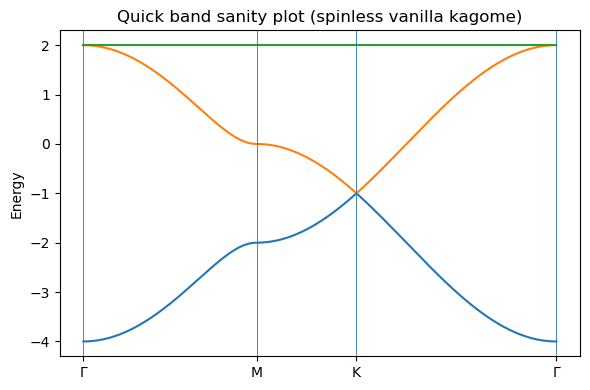

In [8]:
# 6) optional quick plots
b1 = np.array(spinless_model.b1, dtype=float)
b2 = np.array(spinless_model.b2, dtype=float)
Gamma = np.array([0.0, 0.0])
M = 0.5 * b2
K = (2.0*b2 - b1)/3.0
path = [Gamma, M, K, Gamma]
labels = ['Γ','M','K','Γ']

ks = []
xs = []
node_x = [0.0]
cur = 0.0
nseg = 100
for i in range(len(path)-1):
    p0 = np.array(path[i], float)
    p1 = np.array(path[i+1], float)
    for j in range(nseg):
        t = j/nseg
        k = (1-t)*p0 + t*p1
        ks.append(k)
        xs.append(cur + np.linalg.norm(k-p0))
    cur += np.linalg.norm(p1-p0)
    node_x.append(cur)
ks.append(path[-1]); xs.append(cur)

bands = []
for k in ks:
    bands.append(np.linalg.eigvalsh(spinless_model.Hk(k[0], k[1])))
bands = np.array(bands)

plt.figure(figsize=(6,4))
for n in range(bands.shape[1]):
    plt.plot(xs, bands[:, n])
for x in node_x:
    plt.axvline(x, lw=0.6)
plt.xticks(node_x, labels)
plt.ylabel('Energy')
plt.title('Quick band sanity plot (spinless vanilla kagome)')
plt.tight_layout()
plt.show()


In [9]:
summarize_results()


Total tests: 21 | PASS: 21 | FAIL: 0
[01] PASS | spinless Hermiticity #0
      max|H-H^†|=0.000e+00
     value = 0.0
[02] PASS | spinless Hermiticity #1
      max|H-H^†|=0.000e+00
     value = 0.0
[03] PASS | spinless Hermiticity #2
      max|H-H^†|=0.000e+00
     value = 0.0
[04] PASS | spinless Hermiticity #3
      max|H-H^†|=0.000e+00
     value = 0.0
[05] PASS | spinful Hermiticity #0
      max|H-H^†|=0.000e+00
     value = 0.0
[06] PASS | spinful Hermiticity #1
      max|H-H^†|=0.000e+00
     value = 0.0
[07] PASS | spinful Hermiticity #2
      max|H-H^†|=0.000e+00
     value = 0.0
[08] PASS | spinful Hermiticity #3
      max|H-H^†|=0.000e+00
     value = 0.0
[09] PASS | spinful block diagonal #0
      max|up-down block|=0.000e+00
     value = 0.0
[10] PASS | spinful block diagonal #1
      max|up-down block|=0.000e+00
     value = 0.0
[11] PASS | spinful block diagonal #2
      max|up-down block|=0.000e+00
     value = 0.0
[12] PASS | spinful block diagonal #3
      max|up-down b

0